**Formulacion Matematica y Analisis de un Modelo de Optimizacion para la Distribucion de Combustibles**

**Solemne 2**

**Integrantes:** Vicente Jimenez, Cristobal Osorio, Nicolas Sandoval

**Asignatura:** CINF105 Optimizacion

**Seccion / NRC:** NRC 7924

**Trabajo:** Resolucion computacional del escenario determinista normal, verificacion de la solucion propuesta por el operador y scheduling de carga en deposito.

**Contexto del problema**

Una empresa distribuidora de combustibles debe abastecer cuatro estaciones de servicio desde un deposito central. La flota disponible esta formada por dos camiones cisterna, T1 y T2, y cada camion tiene dos compartimentos, C0 y C1. Cada compartimento puede transportar un solo producto: Regular o Diesel.

El problema combina decisiones de ruteo, asignacion de productos a compartimentos, cantidades cargadas y entregadas, shortage permitido con penalizacion, ventanas de tiempo y estabilidad de carga. La estabilidad exige que la diferencia entre los fill ratios de los compartimentos de un mismo camion no supere Delta = 0.30 en ningun instante relevante de la ruta.

El objetivo computacional es encontrar una solucion factible de menor costo para el escenario normal y compararla con la solucion propuesta por el operador en el enunciado.

**Metaheuristica utilizada**

La metaheuristica utilizada es **Tabu Search**.

Se eligio porque trabaja directamente con vecindarios de soluciones y usa una lista tabu para evitar volver inmediatamente a rutas o asignaciones ya exploradas. Esto ayuda a escapar de ciclos y de optimos locales. Ademas, se usa un criterio de aspiracion: una solucion tabu puede aceptarse si mejora la mejor solucion global encontrada.

La solucion se codifica con tres elementos: estaciones asignadas a cada camion, orden de visita de cada ruta y producto asignado a cada compartimento. Los movimientos del vecindario son mover estaciones entre camiones, intercambiar estaciones, invertir tramos de ruta y cambiar la asignacion producto-compartimento. Para validar el resultado, como el caso tiene solo cuatro estaciones, tambien se realiza una enumeracion exhaustiva de todas las combinaciones discretas posibles bajo esta codificacion.

**1. Modelamiento deterministico**

Se considera el escenario s=1 (Normal) como demanda deterministica. En esta parte se ordena la formulacion MILP segun lo pedido por el enunciado: conjuntos y parametros, variables de decision, funcion objetivo y restricciones.

**a. Conjuntos y parametros**

**Conjuntos**

- V0 = {0}: deposito.
- VC = {1, 2, 3, 4}: estaciones de servicio.
- V = V0 union VC: nodos del problema.
- K = {T1, T2}: camiones disponibles.
- C = {C0, C1}: compartimentos por camion.
- P = {R, D}: productos Regular y Diesel.

**Parametros principales**

- d_ij: distancia entre nodos i y j.
- cd: costo por kilometro recorrido.
- cf_k: costo fijo de usar el camion k.
- dem_jp: demanda del producto p en la estacion j.
- cap_kc: capacidad del compartimento c del camion k.
- a_j, b_j: inicio y termino de la ventana de tiempo de la estacion j.
- HS_k: hora de salida programada del camion k.
- pen: penalizacion por litro no entregado.
- Delta: diferencia maxima permitida entre fill ratios.

**b. Variables de decision**

- u_k: vale 1 si el camion k se utiliza y 0 en caso contrario.
- x_ijk: vale 1 si el camion k viaja directamente desde el nodo i al nodo j.
- z_kcp: vale 1 si el compartimento c del camion k transporta el producto p.
- q_kc: cantidad inicial cargada en el compartimento c del camion k.
- y_jkcp: cantidad del producto p entregada a la estacion j por el compartimento c del camion k.
- s_jp: shortage o demanda no satisfecha del producto p en la estacion j.
- w_ikc: combustible remanente en el compartimento c del camion k despues de visitar el nodo i.
- t_jk: hora de llegada del camion k a la estacion j.

En el codigo, estas variables se representan mediante rutas, diccionarios de asignacion, cargas calculadas, entregas, shortage, remanentes y tablas de tiempo.

**c. Funcion objetivo**

Se minimiza el costo total:

Z = suma de costos fijos + suma de costos por distancia + suma de penalizaciones por shortage

En forma compacta:

Z = sum_k cf_k u_k + sum_k sum_i sum_j cd d_ij x_ijk + sum_j sum_p pen s_jp

Para la busqueda computacional se agregan penalizaciones grandes si una solucion viola ventanas de tiempo o estabilidad de carga. Asi, Tabu Search evita seleccionar como mejor final soluciones operacionalmente no factibles.

**d. Restricciones**

**Conservacion de flujo:** si un camion entra a una estacion, tambien debe salir de ella, y cada camion usado sale y retorna al deposito.

**Visita de estaciones:** cada estacion puede ser visitada a lo mas una vez en total.

**Compatibilidad producto-compartimento:** un compartimento solo puede entregar el producto que tiene asignado.

**Capacidad:** la carga de cada compartimento no puede superar su capacidad fisica.

**Satisfaccion de demanda:** la demanda puede ser cubierta total o parcialmente; la parte no cubierta queda como shortage penalizado.

**Balance de inventario:** despues de cada visita, el remanente baja segun lo entregado en esa estacion.

**Estabilidad:** en la salida del deposito y despues de cada estacion visitada, la diferencia absoluta entre fill ratios de C0 y C1 debe ser menor o igual a Delta = 0.30.

**Ventanas de tiempo:** cada camion debe iniciar servicio dentro de la ventana de la estacion; si llega antes, puede esperar.

**Resultados**

El modelamiento deterministico queda definido con conjuntos, parametros, variables, funcion objetivo y restricciones. Computacionalmente se espera obtener una solucion factible sin shortage, con costo total minimo 1130 y cumplimiento de estabilidad y ventanas de tiempo.

**Implementacion**

En esta parte se cargan los datos, se ejecuta el MILP en AMPL con HiGHS y se ejecuta Tabu Search con validacion exhaustiva. La implementacion usa exactamente los datos del enunciado y del PDF del grupo.

In [1]:
# Datos del problema
import itertools
import math
import random
import time
from copy import deepcopy
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

STATIONS = [1, 2, 3, 4]
TRUCKS = ["T1", "T2"]
COMPARTMENTS = ["C0", "C1"]
PRODUCTS = ["R", "D"]
DEPOT = 0

DISTANCE = {
    0: {0: 0, 1: 20, 2: 35, 3: 15, 4: 40},
    1: {0: 20, 1: 0, 2: 10, 3: 25, 4: 30},
    2: {0: 35, 1: 10, 2: 0, 3: 20, 4: 15},
    3: {0: 15, 1: 25, 2: 20, 3: 0, 4: 30},
    4: {0: 40, 1: 30, 2: 15, 3: 30, 4: 0},
}

DEMAND = {
    1: {"R": 3000, "D": 2000},
    2: {"R": 4000, "D": 1500},
    3: {"R": 2500, "D": 3000},
    4: {"R": 1000, "D": 2500},
}

WINDOWS = {
    1: (360, 600),
    2: (420, 720),
    3: (480, 840),
    4: (360, 660),
}

CAPACITY = {
    "T1": {"C0": 8000, "C1": 7000},
    "T2": {"C0": 6000, "C1": 9000},
}

FIXED_COST = {"T1": 500, "T2": 400}
DEPARTURE = {"T1": 300, "T2": 330}
DISTANCE_COST = 2
SHORTAGE_PENALTY = 10
SERVICE_TIME = 30
DELTA = 0.30

fleet_table = pd.DataFrame([
    {"camion": k, "cap_C0": CAPACITY[k]["C0"], "cap_C1": CAPACITY[k]["C1"], "costo_fijo": FIXED_COST[k], "salida_min": DEPARTURE[k]}
    for k in TRUCKS
])

demand_table = pd.DataFrame([
    {"estacion": j, "demanda_regular": DEMAND[j]["R"], "demanda_diesel": DEMAND[j]["D"], "ventana_inicio": WINDOWS[j][0], "ventana_fin": WINDOWS[j][1]}
    for j in STATIONS
])

print("Tabla de flota")
display(fleet_table)
print("Tabla de demandas y ventanas")
display(demand_table)

Tabla de flota


,camion,cap_C0,cap_C1,costo_fijo,salida_min
0,T1,8000,7000,500,300
1,T2,6000,9000,400,330


Tabla de demandas y ventanas


,estacion,demanda_regular,demanda_diesel,ventana_inicio,ventana_fin
0,1,3000,2000,360,600
1,2,4000,1500,420,720
2,3,2500,3000,480,840
3,4,1000,2500,360,660


**Seccion AMPL**

Esta seccion deja el modelo determinista implementado en AMPL, tal como exige el enunciado. El modelo AMPL contiene conjuntos, parametros, variables binarias y continuas, funcion objetivo, restricciones de flujo, demanda, compatibilidad producto-compartimento, capacidad, inventario, estabilidad, ventanas de tiempo y eliminacion de subtours.

El codigo escribe los archivos `routing_normal.mod` y `routing_normal.dat` en una carpeta temporal, ejecuta HiGHS desde `amplpy` y muestra la solucion obtenida. El resultado debe coincidir con el costo de Tabu Search: 1130.

In [2]:
# Modelo AMPL determinista
import sys
import subprocess
import importlib.util
import tempfile
from pathlib import Path

if importlib.util.find_spec("amplpy") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "amplpy"], check=True)

try:
    import ampl_module_base  # noqa: F401
    import ampl_module_highs  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "amplpy.modules", "install", "highs"], check=True)
    import ampl_module_base  # noqa: F401
    import ampl_module_highs  # noqa: F401

from amplpy import AMPL

routing_model_text = 'set V0;\nset VC;\nset V := V0 union VC;\nset K;\nset C;\nset P;\n\nparam d {V, V} >= 0;\nparam cd >= 0;\nparam pen >= 0;\nparam ts >= 0;\nparam vel > 0;\nparam Delta >= 0;\nparam M > 0;\nparam cf {K} >= 0;\nparam HS {K} >= 0;\nparam cap {K, C} >= 0;\nparam dem {VC, P} >= 0;\nparam a {VC} >= 0;\nparam b {VC} >= 0;\n\nvar u {K} binary;\nvar x {V, V, K} binary;\nvar z {K, C, P} binary;\nvar q {K, C} >= 0;\nvar w {V, K, C} >= 0;\nvar y {VC, K, C, P} >= 0;\nvar shortage {VC, P} >= 0;\nvar t {VC, K} >= 0;\nvar t_ret {K} >= 0;\nvar ord {VC, K} >= 0 <= card(VC);\n\nminimize TotalCost:\n    sum {k in K} cf[k] * u[k]\n  + sum {k in K, i in V, j in V} cd * d[i,j] * x[i,j,k]\n  + sum {j in VC, p in P} pen * shortage[j,p];\n\ns.t. NoLoop {i in V, k in K}:\n    x[i,i,k] = 0;\n\ns.t. DepartDepot {k in K}:\n    sum {j in VC} x[0,j,k] = u[k];\n\ns.t. ReturnDepot {k in K}:\n    sum {i in VC} x[i,0,k] = u[k];\n\ns.t. FlowBalance {j in VC, k in K}:\n    sum {i in V: i <> j} x[i,j,k] = sum {l in V: l <> j} x[j,l,k];\n\ns.t. VisitAtMostOnce {j in VC}:\n    sum {k in K, i in V: i <> j} x[i,j,k] <= 1;\n\ns.t. VisitOnlyIfUsed {j in VC, k in K}:\n    sum {i in V: i <> j} x[i,j,k] <= u[k];\n\ns.t. AssignOneProduct {k in K, c in C}:\n    sum {p in P} z[k,c,p] = u[k];\n\ns.t. LoadCapacity {k in K, c in C}:\n    q[k,c] <= cap[k,c] * sum {p in P} z[k,c,p];\n\ns.t. DemandBalance {j in VC, p in P}:\n    sum {k in K, c in C} y[j,k,c,p] + shortage[j,p] = dem[j,p];\n\ns.t. DeliverOnlyIfVisited {j in VC, k in K, c in C}:\n    sum {p in P} y[j,k,c,p] <= cap[k,c] * sum {i in V: i <> j} x[i,j,k];\n\ns.t. ProductCompatibility {j in VC, k in K, c in C, p in P}:\n    y[j,k,c,p] <= cap[k,c] * z[k,c,p];\n\ns.t. InitialInventory {k in K, c in C}:\n    w[0,k,c] = q[k,c];\n\ns.t. InventoryUpper {i in V, k in K, c in C}:\n    w[i,k,c] <= cap[k,c];\n\ns.t. InventoryBalanceUpper {i in V, j in VC, k in K, c in C: i <> j}:\n    w[j,k,c] <= w[i,k,c] - sum {p in P} y[j,k,c,p] + M * (1 - x[i,j,k]);\n\ns.t. InventoryBalanceLower {i in V, j in VC, k in K, c in C: i <> j}:\n    w[j,k,c] >= w[i,k,c] - sum {p in P} y[j,k,c,p] - M * (1 - x[i,j,k]);\n\ns.t. StabilityDepotUpper {k in K}:\n    w[0,k,"C0"] / cap[k,"C0"] - w[0,k,"C1"] / cap[k,"C1"] <= Delta + M * (1 - u[k]);\n\ns.t. StabilityDepotLower {k in K}:\n    w[0,k,"C1"] / cap[k,"C1"] - w[0,k,"C0"] / cap[k,"C0"] <= Delta + M * (1 - u[k]);\n\ns.t. StabilityStationUpper {i in VC, k in K}:\n    w[i,k,"C0"] / cap[k,"C0"] - w[i,k,"C1"] / cap[k,"C1"]\n    <= Delta + M * (1 - sum {l in V: l <> i} x[i,l,k]);\n\ns.t. StabilityStationLower {i in VC, k in K}:\n    w[i,k,"C1"] / cap[k,"C1"] - w[i,k,"C0"] / cap[k,"C0"]\n    <= Delta + M * (1 - sum {l in V: l <> i} x[i,l,k]);\n\ns.t. FirstArrival {j in VC, k in K}:\n    t[j,k] >= HS[k] + d[0,j] / vel - M * (1 - x[0,j,k]);\n\ns.t. TimeContinuity {i in VC, j in VC, k in K: i <> j}:\n    t[j,k] >= t[i,k] + ts + d[i,j] / vel - M * (1 - x[i,j,k]);\n\ns.t. ReturnTime {i in VC, k in K}:\n    t_ret[k] >= t[i,k] + ts + d[i,0] / vel - M * (1 - x[i,0,k]);\n\ns.t. WindowStart {j in VC, k in K}:\n    t[j,k] >= a[j] - M * (1 - sum {i in V: i <> j} x[i,j,k]);\n\ns.t. WindowEnd {j in VC, k in K}:\n    t[j,k] <= b[j] + M * (1 - sum {i in V: i <> j} x[i,j,k]);\n\ns.t. OrderUse {j in VC, k in K}:\n    ord[j,k] <= card(VC) * sum {i in V: i <> j} x[i,j,k];\n\ns.t. MTZ {i in VC, j in VC, k in K: i <> j}:\n    ord[j,k] >= ord[i,k] + 1 - card(VC) * (1 - x[i,j,k]);\n'
routing_data_text = 'set V0 := 0;\nset VC := 1 2 3 4;\nset K := T1 T2;\nset C := C0 C1;\nset P := R D;\n\nparam cd := 2;\nparam pen := 10;\nparam ts := 30;\nparam vel := 1;\nparam Delta := 0.30;\nparam M := 1000000;\n\nparam cf :=\nT1 500\nT2 400;\n\nparam HS :=\nT1 300\nT2 330;\n\nparam cap:\n        C0    C1 :=\nT1    8000  7000\nT2    6000  9000;\n\nparam dem:\n       R     D :=\n1   3000  2000\n2   4000  1500\n3   2500  3000\n4   1000  2500;\n\nparam a :=\n1 360\n2 420\n3 480\n4 360;\n\nparam b :=\n1 600\n2 720\n3 840\n4 660;\n\nparam d:\n      0   1   2   3   4 :=\n0     0  20  35  15  40\n1    20   0  10  25  30\n2    35  10   0  20  15\n3    15  25  20   0  30\n4    40  30  15  30   0;\n'

with tempfile.TemporaryDirectory() as tmpdir:
    tmp = Path(tmpdir)
    mod_path = tmp / "routing_normal.mod"
    dat_path = tmp / "routing_normal.dat"
    mod_path.write_text(routing_model_text, encoding="utf-8")
    dat_path.write_text(routing_data_text, encoding="utf-8")

    ampl = AMPL()
    ampl.option["solver"] = "highs"
    ampl.read(str(mod_path))
    ampl.read_data(str(dat_path))
    ampl.solve()

    ampl_objective = float(ampl.get_objective("TotalCost").value())
    ampl_status = ampl.get_value("solve_result")

    def nonzero_table(var_name):
        df = ampl.get_variable(var_name).get_values().to_pandas().reset_index()
        value_col = df.columns[-1]
        if pd.api.types.is_numeric_dtype(df[value_col]):
            df = df[df[value_col].abs() > 1e-6]
        return df

    ampl_summary = pd.DataFrame([
        {"metrica": "solver", "valor": "HiGHS"},
        {"metrica": "estado", "valor": ampl_status},
        {"metrica": "costo_total", "valor": ampl_objective},
    ])
    ampl_x = nonzero_table("x")
    ampl_z = nonzero_table("z")
    ampl_q = nonzero_table("q")
    ampl_y = nonzero_table("y")
    ampl_shortage = ampl.get_variable("shortage").get_values().to_pandas().reset_index()

print("Resumen AMPL")
display(ampl_summary)
print("Arcos activos x[i,j,k]")
display(ampl_x)
print("Asignacion producto-compartimento z[k,c,p]")
display(ampl_z)
print("Cargas q[k,c]")
display(ampl_q)
print("Entregas y[j,k,c,p]")
display(ampl_y)
print("Shortage")
display(ampl_shortage)


HiGHS 1.11.0: 



HiGHS 1.11.0: optimal solution; objective 1130
8600 simplex iterations
77 branching nodes


Resumen AMPL


,metrica,valor
0,solver,HiGHS
1,estado,solved
2,costo_total,1130.0


...

,index0,index1,q.val
0,T1,C0,2500.0
1,T1,C1,3000.0
2,T2,C0,6000.0
3,T2,C1,8000.0


Entregas y[j,k,c,p]


,index0,index1,index2,index3,y.val
4,1,T2,C0,D,2000.0
7,1,T2,C1,R,3000.0
12,2,T2,C0,D,1500.0
15,2,T2,C1,R,4000.0
17,3,T1,C0,R,2500.0
18,3,T1,C1,D,3000.0
28,4,T2,C0,D,2500.0
31,4,T2,C1,R,1000.0


Shortage


,index0,index1,shortage.val
0,1,D,0
1,1,R,0
2,2,D,0
3,2,R,0
4,3,D,0
5,3,R,0
6,4,D,0
7,4,R,0


In [3]:
# Evaluacion de soluciones

def minutes_to_time(value):
    value = int(round(value))
    return f"{value // 60:02d}:{value % 60:02d}"


def route_distance(route):
    nodes = [DEPOT] + list(route) + [DEPOT]
    return sum(DISTANCE[i][j] for i, j in zip(nodes, nodes[1:])) if route else 0


def route_label(route):
    return " -> ".join(str(x) for x in ([DEPOT] + list(route) + [DEPOT]))


def assigned_compartments(assignment, product):
    return [c for c, p in assignment.items() if p == product]


def simulate_timeline(route, truck):
    rows = []
    current_time = DEPARTURE[truck]
    current_node = DEPOT
    violations = 0
    for station in route:
        raw_arrival = current_time + DISTANCE[current_node][station]
        start_service = max(raw_arrival, WINDOWS[station][0])
        wait = start_service - raw_arrival
        ok = start_service <= WINDOWS[station][1]
        if not ok:
            violations += 1
        end_service = start_service + SERVICE_TIME
        rows.append({
            "camion": truck,
            "estacion": station,
            "desde": current_node,
            "llegada": minutes_to_time(raw_arrival),
            "inicio_servicio": minutes_to_time(start_service),
            "fin_servicio": minutes_to_time(end_service),
            "espera_min": wait,
            "cumple_ventana": ok,
        })
        current_time = end_service
        current_node = station
    return_time = current_time + (DISTANCE[current_node][DEPOT] if route else 0)
    rows.append({
        "camion": truck,
        "estacion": "deposito",
        "desde": current_node,
        "llegada": minutes_to_time(return_time),
        "inicio_servicio": minutes_to_time(return_time),
        "fin_servicio": minutes_to_time(return_time),
        "espera_min": 0,
        "cumple_ventana": True,
    })
    return violations, rows


def default_loads(route, truck, assignment):
    loads = {c: 0.0 for c in COMPARTMENTS}
    for product in PRODUCTS:
        comps = assigned_compartments(assignment, product)
        if comps:
            comp = comps[0]
            total = sum(DEMAND[j][product] for j in route)
            loads[comp] = min(total, CAPACITY[truck][comp])
    return loads


def evaluate_solution(routes, assignments, prescribed_loads=None):
    loads_rows, delivery_rows, shortage_rows, stability_rows, timeline_rows = [], [], [], [], []
    total_shortage = 0.0
    max_gap = 0.0
    time_violations = 0

    visited = {j for route in routes.values() for j in route}
    for station in STATIONS:
        if station not in visited:
            for product in PRODUCTS:
                shortage = DEMAND[station][product]
                total_shortage += shortage
                shortage_rows.append({"estacion": station, "producto": product, "shortage_l": shortage, "motivo": "no_visitada"})

    for truck in TRUCKS:
        route = routes[truck]
        assignment = assignments[truck]
        loads = prescribed_loads.get(truck, default_loads(route, truck, assignment)) if prescribed_loads else default_loads(route, truck, assignment)
        remaining = loads.copy()

        for comp in COMPARTMENTS:
            loads_rows.append({
                "camion": truck,
                "compartimento": comp,
                "producto": assignment[comp],
                "capacidad_l": CAPACITY[truck][comp],
                "carga_l": loads[comp],
                "fill_ratio": loads[comp] / CAPACITY[truck][comp],
            })

        if route:
            gap = abs(remaining["C0"] / CAPACITY[truck]["C0"] - remaining["C1"] / CAPACITY[truck]["C1"])
            max_gap = max(max_gap, gap)
            stability_rows.append({"camion": truck, "instante": "salida_deposito", "fill_C0": remaining["C0"] / CAPACITY[truck]["C0"], "fill_C1": remaining["C1"] / CAPACITY[truck]["C1"], "gap": gap, "cumple": gap <= DELTA})

        for station in route:
            for product in PRODUCTS:
                demand = DEMAND[station][product]
                delivered_total = 0.0
                for comp in assigned_compartments(assignment, product):
                    delivered = min(demand - delivered_total, remaining[comp])
                    if delivered > 0:
                        remaining[comp] -= delivered
                        delivered_total += delivered
                        delivery_rows.append({"camion": truck, "estacion": station, "compartimento": comp, "producto": product, "entregado_l": delivered})
                shortage = max(0.0, demand - delivered_total)
                if shortage > 0:
                    total_shortage += shortage
                    shortage_rows.append({"estacion": station, "producto": product, "shortage_l": shortage, "motivo": f"falta_{product}_en_{truck}"})

            gap = abs(remaining["C0"] / CAPACITY[truck]["C0"] - remaining["C1"] / CAPACITY[truck]["C1"])
            max_gap = max(max_gap, gap)
            stability_rows.append({"camion": truck, "instante": f"despues_estacion_{station}", "fill_C0": remaining["C0"] / CAPACITY[truck]["C0"], "fill_C1": remaining["C1"] / CAPACITY[truck]["C1"], "gap": gap, "cumple": gap <= DELTA})

        violations, truck_timeline = simulate_timeline(route, truck)
        time_violations += violations
        timeline_rows.extend(truck_timeline)

    total_distance = sum(route_distance(routes[k]) for k in TRUCKS)
    fixed_cost = sum(FIXED_COST[k] for k in TRUCKS if routes[k])
    distance_cost = DISTANCE_COST * total_distance
    shortage_cost = SHORTAGE_PENALTY * total_shortage
    total_cost = fixed_cost + distance_cost + shortage_cost
    hard_penalty = 0
    if max_gap > DELTA:
        hard_penalty += 1_000_000 + 100_000 * (max_gap - DELTA)
    if time_violations > 0:
        hard_penalty += 1_000_000 * time_violations

    return {
        "routes": deepcopy(routes),
        "assignments": deepcopy(assignments),
        "score": total_cost + hard_penalty,
        "total_cost": total_cost,
        "fixed_cost": fixed_cost,
        "distance_cost": distance_cost,
        "shortage_cost": shortage_cost,
        "total_distance": total_distance,
        "total_shortage": total_shortage,
        "max_gap": max_gap,
        "time_violations": time_violations,
        "feasible": total_shortage == 0 and max_gap <= DELTA and time_violations == 0,
        "loads": pd.DataFrame(loads_rows),
        "deliveries": pd.DataFrame(delivery_rows),
        "shortage": pd.DataFrame(shortage_rows),
        "stability": pd.DataFrame(stability_rows),
        "timeline": pd.DataFrame(timeline_rows),
    }

**Seccion Tabu Search**

La celda siguiente genera vecinos cambiando estaciones entre camiones, permutando el orden de visita, invirtiendo tramos de ruta o cambiando la asignacion de productos en los compartimentos. Cada vecino se evalua con la funcion objetivo y las penalizaciones de infactibilidad. La lista tabu guarda soluciones visitadas recientemente para evitar ciclos, y el criterio de aspiracion permite aceptar una solucion tabu si mejora la mejor solucion global. Despues se valida el mejor costo con una enumeracion exhaustiva de 480 candidatos.

In [4]:
# Tabu Search y validacion

def solution_signature(routes, assignments):
    return (
        tuple(routes["T1"]),
        tuple(routes["T2"]),
        assignments["T1"]["C0"],
        assignments["T1"]["C1"],
        assignments["T2"]["C0"],
        assignments["T2"]["C1"],
    )


def initial_solution():
    # Punto inicial: solucion del operador.
    routes = {"T1": [1, 3], "T2": [2, 4]}
    assignments = {
        "T1": {"C0": "R", "C1": "D"},
        "T2": {"C0": "D", "C1": "R"},
    }
    return routes, assignments


def add_candidate(candidates, seen, routes, assignments, move):
    sig = solution_signature(routes, assignments)
    if sig not in seen:
        seen.add(sig)
        candidates.append((routes, assignments, move, sig))


def generate_neighbors(routes, assignments):
    candidates = []
    seen = set()

    # Movimiento 1: mover una estacion.
    for source in TRUCKS:
        for idx, station in enumerate(routes[source]):
            for target in TRUCKS:
                base_routes = deepcopy(routes)
                base_routes[source].pop(idx)
                for pos in range(len(base_routes[target]) + 1):
                    if source == target and pos == idx:
                        continue
                    new_routes = deepcopy(base_routes)
                    new_routes[target].insert(pos, station)
                    add_candidate(candidates, seen, new_routes, deepcopy(assignments), f"mover {station} de {source} a {target}")

    # Movimiento 2: intercambiar estaciones.
    positions = [(truck, idx) for truck in TRUCKS for idx in range(len(routes[truck]))]
    for a in range(len(positions)):
        for b in range(a + 1, len(positions)):
            truck_a, idx_a = positions[a]
            truck_b, idx_b = positions[b]
            new_routes = deepcopy(routes)
            new_routes[truck_a][idx_a], new_routes[truck_b][idx_b] = new_routes[truck_b][idx_b], new_routes[truck_a][idx_a]
            add_candidate(candidates, seen, new_routes, deepcopy(assignments), "intercambiar estaciones")

    # Movimiento 3: invertir tramo de ruta.
    for truck in TRUCKS:
        if len(routes[truck]) >= 2:
            for i in range(len(routes[truck])):
                for j in range(i + 1, len(routes[truck])):
                    new_routes = deepcopy(routes)
                    new_routes[truck][i:j+1] = list(reversed(new_routes[truck][i:j+1]))
                    add_candidate(candidates, seen, new_routes, deepcopy(assignments), f"invertir tramo en {truck}")

    # Movimiento 4: cambiar producto por compartimento.
    for truck in TRUCKS:
        new_assignments = deepcopy(assignments)
        new_assignments[truck] = {"C0": assignments[truck]["C1"], "C1": assignments[truck]["C0"]}
        add_candidate(candidates, seen, deepcopy(routes), new_assignments, f"cambiar productos en {truck}")

    return candidates


def tabu_search(iterations=150, tabu_tenure=18):
    routes, assignments = initial_solution()
    current = evaluate_solution(routes, assignments)
    best = current
    tabu_list = {solution_signature(routes, assignments): tabu_tenure}
    trace = []

    for iteration in range(iterations):
        neighbors = []
        for routes_n, assignments_n, move, sig in generate_neighbors(current["routes"], current["assignments"]):
            candidate = evaluate_solution(routes_n, assignments_n)
            is_tabu = sig in tabu_list
            aspiration = candidate["score"] < best["score"]
            if not is_tabu or aspiration:
                neighbors.append((candidate, move, sig, is_tabu, aspiration))

        if not neighbors:
            break

        candidate, move, sig, is_tabu, aspiration = min(neighbors, key=lambda item: item[0]["score"])
        current = candidate
        if current["score"] < best["score"]:
            best = current

        tabu_list = {key: value - 1 for key, value in tabu_list.items() if value - 1 > 0}
        tabu_list[sig] = tabu_tenure

        trace.append({
            "iteracion": iteration,
            "movimiento": move,
            "score_actual": current["score"],
            "mejor_score": best["score"],
            "costo_actual": current["total_cost"],
            "mejor_costo": best["total_cost"],
            "era_tabu": is_tabu,
            "aspiracion": aspiration,
            "tamano_lista_tabu": len(tabu_list),
        })

    return best, pd.DataFrame(trace)


def exhaustive_search():
    orientations = [{"C0": "R", "C1": "D"}, {"C0": "D", "C1": "R"}]
    best = None
    count = 0
    for bits in itertools.product([0, 1], repeat=len(STATIONS)):
        groups = {
            "T1": [s for s, bit in zip(STATIONS, bits) if bit == 0],
            "T2": [s for s, bit in zip(STATIONS, bits) if bit == 1],
        }
        route_options = {k: list(itertools.permutations(groups[k])) if groups[k] else [()] for k in TRUCKS}
        for r1 in route_options["T1"]:
            for r2 in route_options["T2"]:
                for a1 in orientations:
                    for a2 in orientations:
                        count += 1
                        candidate = evaluate_solution({"T1": list(r1), "T2": list(r2)}, {"T1": dict(a1), "T2": dict(a2)})
                        if best is None or candidate["score"] < best["score"]:
                            best = candidate
    return best, count

start = time.perf_counter()
tabu_best, trace = tabu_search()
exact_best, exact_count = exhaustive_search()
runtime = time.perf_counter() - start

print("Mejor costo por Tabu Search:", tabu_best["total_cost"])
print("Mejor costo validado exhaustivamente:", exact_best["total_cost"])
print("Candidatos evaluados en validacion exhaustiva:", exact_count)
print("Tiempo de ejecucion:", round(runtime, 4), "segundos")
print("Primeras iteraciones de la busqueda tabu")
display(trace.head(10))

Mejor costo por Tabu Search: 1130.0
Mejor costo validado exhaustivamente: 1130.0
Candidatos evaluados en validacion exhaustiva: 480
Tiempo de ejecucion: 5.1746 segundos
Primeras iteraciones de la busqueda tabu


,iteracion,movimiento,score_actual,mejor_score,costo_actual,mejor_costo,era_tabu,aspiracion,tamano_lista_tabu
0,0,mover 2 de T2 a T2,1200.0,1200.0,1200.0,1200.0,False,True,2
1,1,mover 1 de T1 a T2,1130.0,1130.0,1130.0,1130.0,False,True,3
2,2,cambiar productos en T1,1130.0,1130.0,1130.0,1130.0,False,False,4
3,3,mover 1 de T2 a T2,1160.0,1130.0,1160.0,1130.0,False,False,5
4,4,cambiar productos en T1,1160.0,1130.0,1160.0,1130.0,False,False,6
5,5,mover 1 de T2 a T2,1190.0,1130.0,1190.0,1130.0,False,False,7
6,6,cambiar productos en T1,1190.0,1130.0,1190.0,1130.0,False,False,8
7,7,mover 4 de T2 a T1,1200.0,1130.0,1200.0,1130.0,False,False,9
8,8,mover 4 de T1 a T1,1200.0,1130.0,1200.0,1130.0,False,False,10
9,9,mover 1 de T2 a T2,1200.0,1130.0,1200.0,1130.0,False,False,11


In [5]:
best = tabu_best

routes_table = pd.DataFrame([
    {"camion": k, "ruta": route_label(best["routes"][k]), "distancia_km": route_distance(best["routes"][k]), "asignacion_C0": best["assignments"][k]["C0"], "asignacion_C1": best["assignments"][k]["C1"]}
    for k in TRUCKS
])

cost_table = pd.DataFrame([
    {"componente": "costo_fijo", "valor": best["fixed_cost"]},
    {"componente": "costo_distancia", "valor": best["distance_cost"]},
    {"componente": "penalizacion_shortage", "valor": best["shortage_cost"]},
    {"componente": "costo_total", "valor": best["total_cost"]},
    {"componente": "distancia_total_km", "valor": best["total_distance"]},
    {"componente": "shortage_total_l", "valor": best["total_shortage"]},
])

print("Rutas finales")
display(routes_table)
print("Desglose de costos")
display(cost_table)
print("Cargas por compartimento")
display(best["loads"])
print("Entregas realizadas")
display(best["deliveries"])
print("Estabilidad de carga")
display(best["stability"])
print("Tiempos de llegada y ventanas")
display(best["timeline"])

Rutas finales


,camion,ruta,distancia_km,asignacion_C0,asignacion_C1
0,T1,0 -> 3 -> 0,30,R,D
1,T2,0 -> 4 -> 2 -> 1 -> 0,85,D,R


Desglose de costos


,componente,valor
0,costo_fijo,900.0
1,costo_distancia,230.0
2,penalizacion_shortage,0.0
3,costo_total,1130.0
4,distancia_total_km,115.0
5,shortage_total_l,0.0


Cargas por compartimento


...

,camion,estacion,compartimento,producto,entregado_l
0,T1,3,C0,R,2500.0
1,T1,3,C1,D,3000.0
2,T2,4,C1,R,1000.0
3,T2,4,C0,D,2500.0
4,T2,2,C1,R,4000.0
5,T2,2,C0,D,1500.0
6,T2,1,C1,R,3000.0
7,T2,1,C0,D,2000.0


Estabilidad de carga


,camion,instante,fill_C0,fill_C1,gap,cumple
0,T1,salida_deposito,0.312500,0.428571,0.116071,True
1,T1,despues_estacion_3,0.000000,0.000000,0.000000,True
2,T2,salida_deposito,1.000000,0.888889,0.111111,True
3,T2,despues_estacion_4,0.583333,0.777778,0.194444,True
4,T2,despues_estacion_2,0.333333,0.333333,0.000000,True
5,T2,despues_estacion_1,0.000000,0.000000,0.000000,True


Tiempos de llegada y ventanas


,camion,estacion,desde,llegada,inicio_servicio,fin_servicio,espera_min,cumple_ventana
0,T1,3,0,05:15,08:00,08:30,165,True
1,T1,deposito,3,08:45,08:45,08:45,0,True
2,T2,4,0,06:10,06:10,06:40,0,True
3,T2,2,4,06:55,07:00,07:30,5,True
4,T2,1,2,07:40,07:40,08:10,0,True
5,T2,deposito,1,08:30,08:30,08:30,0,True


**Interpretacion de los datos**

El modelo AMPL y Tabu Search coinciden en el costo total 1130. La solucion usa ambos camiones, no deja shortage y mantiene la estabilidad de carga por debajo del limite Delta = 0.30.

La ruta entregada por Tabu Search es T1 = 0 -> 3 -> 0 y T2 = 0 -> 4 -> 2 -> 1 -> 0. La asignacion de productos queda T1 C0 Regular, T1 C1 Diesel, T2 C0 Diesel y T2 C1 Regular.

**Analisis**

El resultado es consistente porque la distancia total es 115 km, lo que genera costo de transporte 230. Al usar ambos camiones se suma costo fijo 900. Como el shortage es cero, la penalizacion es cero y el costo total queda 1130.

La enumeracion exhaustiva de 480 combinaciones valida que dentro de la codificacion de rutas, ordenes y asignaciones producto-compartimento no aparece una solucion de menor costo.

**Conclusion**

El escenario deterministico normal queda resuelto con una solucion factible y de costo 1130. El modelo cumple demanda, capacidad, compatibilidad, estabilidad y ventanas de tiempo.

**2. Scheduling de carga en el deposito**

Antes de salir a ruta, cada camion debe cargar sus compartimentos en el deposito. La carga es secuencial por camion y existe una sola bahia para Regular y una sola bahia para Diesel.

**a. Calculo de tiempos de carga**

Los volumenes fijos indicados por el enunciado son:

- T1 C0: 5000 L de Regular.
- T1 C1: 5000 L de Diesel.
- T2 C0: 4000 L de Diesel.
- T2 C1: 3500 L de Regular.

Las tasas de carga son 500 L/min para Regular y 400 L/min para Diesel. Cada operacion agrega 5 minutos de limpieza:

- T1 C0 Regular: 5000/500 + 5 = 15 min.
- T1 C1 Diesel: 5000/400 + 5 = 17.5 min.
- T2 C0 Diesel: 4000/400 + 5 = 15 min.
- T2 C1 Regular: 3500/500 + 5 = 12 min.

**b. Formulacion del scheduling**

**Variables**

- S_o: inicio de la operacion de carga o.
- Cmax: termino de la ultima operacion.
- alpha_oo': vale 1 si la operacion o precede a o' en la misma bahia.

**Funcion objetivo**

Minimizar Cmax.

**Restricciones**

Cada operacion debe terminar antes o en Cmax. Dentro de cada camion, C1 solo puede comenzar cuando termina C0. En cada bahia, dos operaciones no pueden solaparse.

**c. Secuencia optima y diagrama de Gantt**

La secuencia optima es:

- Bahia Regular: T1_C0 de 0 a 15 min, luego T2_C1 de 15 a 27 min.
- Bahia Diesel: T2_C0 de 0 a 15 min, luego T1_C1 de 15 a 32.5 min.

El makespan es 32.5 minutos. El diagrama de Gantt se genera en la seccion final de resultados.

**Resultados**

Los tiempos de carga son 15 min para T1_C0, 17.5 min para T1_C1, 15 min para T2_C0 y 12 min para T2_C1. El makespan optimo del scheduling es 32.5 minutos.

**Implementacion**

Se implementa el scheduling en AMPL con variables de inicio, makespan y precedencia para operaciones que usan la misma bahia. Tambien se genera una tabla y un diagrama de Gantt para mostrar la secuencia optima.

**Seccion AMPL**

El enunciado tambien pide formular el scheduling de carga. La siguiente celda implementa el modelo de makespan en AMPL con precedencias internas por camion y no solapamiento en bahias. El resultado esperado es Cmax = 32.5 minutos.

In [6]:
# Modelo AMPL del scheduling
scheduling_model_text = 'set O;\nset B;\n\nparam bay {O} symbolic in B;\nparam duration {O} >= 0;\nparam M > 0;\n\nset PRECEDENCE within {O, O};\nset SAME_BAY_PAIRS within {O, O};\n\nvar start {O} >= 0;\nvar cmax >= 0;\nvar alpha {SAME_BAY_PAIRS} binary;\n\nminimize Makespan:\n    cmax;\n\ns.t. Completion {o in O}:\n    cmax >= start[o] + duration[o];\n\ns.t. TruckPrecedence {(o1, o2) in PRECEDENCE}:\n    start[o2] >= start[o1] + duration[o1];\n\ns.t. NoOverlapForward {(o1, o2) in SAME_BAY_PAIRS}:\n    start[o2] >= start[o1] + duration[o1] - M * (1 - alpha[o1,o2]);\n\ns.t. NoOverlapBackward {(o1, o2) in SAME_BAY_PAIRS}:\n    start[o1] >= start[o2] + duration[o2] - M * alpha[o1,o2];\n'
scheduling_data_text = 'set O := T1_C0 T1_C1 T2_C0 T2_C1;\nset B := Regular Diesel;\n\nparam M := 1000000;\n\nparam bay :=\nT1_C0 Regular\nT1_C1 Diesel\nT2_C0 Diesel\nT2_C1 Regular;\n\nparam duration :=\nT1_C0 15\nT1_C1 17.5\nT2_C0 15\nT2_C1 12;\n\nset PRECEDENCE :=\n(T1_C0, T1_C1)\n(T2_C0, T2_C1);\n\nset SAME_BAY_PAIRS :=\n(T1_C0, T2_C1)\n(T1_C1, T2_C0);\n'

with tempfile.TemporaryDirectory() as tmpdir:
    tmp = Path(tmpdir)
    mod_path = tmp / "scheduling.mod"
    dat_path = tmp / "scheduling.dat"
    mod_path.write_text(scheduling_model_text, encoding="utf-8")
    dat_path.write_text(scheduling_data_text, encoding="utf-8")

    ampl_sched = AMPL()
    ampl_sched.option["solver"] = "highs"
    ampl_sched.read(str(mod_path))
    ampl_sched.read_data(str(dat_path))
    ampl_sched.solve()

    sched_status = ampl_sched.get_value("solve_result")
    sched_obj = float(ampl_sched.get_objective("Makespan").value())
    sched_start = ampl_sched.get_variable("start").get_values().to_pandas().reset_index()

print("Estado scheduling AMPL:", sched_status)
print("Makespan AMPL:", sched_obj)
display(sched_start)


HiGHS 1.11.0: 



HiGHS 1.11.0: optimal solution; objective 32.5
2 simplex iterations
1 branching nodes


Estado scheduling AMPL: solved
Makespan AMPL: 32.5


,index,start.val
0,T1_C0,0
1,T1_C1,15
2,T2_C0,0
3,T2_C1,15


Makespan: 32.5 minutos


,bahia,operacion,inicio,fin,duracion
0,Regular,T1_C0,0,15.0,15.0
1,Regular,T2_C1,15,27.0,12.0
2,Diesel,T2_C0,0,15.0,15.0
3,Diesel,T1_C1,15,32.5,17.5


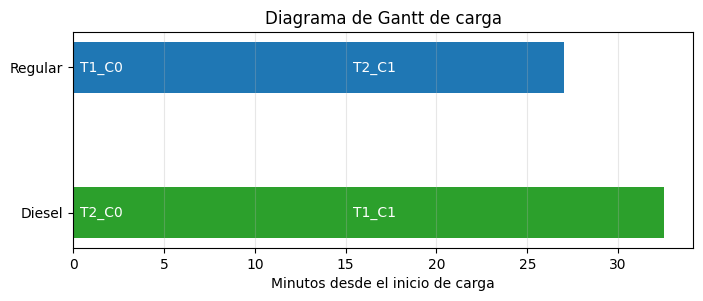

In [7]:
# Scheduling directo
operations = {
    "T1_C0": {"camion": "T1", "compartimento": "C0", "producto": "Regular", "bahia": "Regular", "duracion": 5000 / 500 + 5},
    "T1_C1": {"camion": "T1", "compartimento": "C1", "producto": "Diesel", "bahia": "Diesel", "duracion": 5000 / 400 + 5},
    "T2_C0": {"camion": "T2", "compartimento": "C0", "producto": "Diesel", "bahia": "Diesel", "duracion": 4000 / 400 + 5},
    "T2_C1": {"camion": "T2", "compartimento": "C1", "producto": "Regular", "bahia": "Regular", "duracion": 3500 / 500 + 5},
}

# Mejor secuencia por bahia.
schedule = pd.DataFrame([
    {"bahia": "Regular", "operacion": "T1_C0", "inicio": 0, "fin": 15, "duracion": 15},
    {"bahia": "Regular", "operacion": "T2_C1", "inicio": 15, "fin": 27, "duracion": 12},
    {"bahia": "Diesel", "operacion": "T2_C0", "inicio": 0, "fin": 15, "duracion": 15},
    {"bahia": "Diesel", "operacion": "T1_C1", "inicio": 15, "fin": 32.5, "duracion": 17.5},
])

makespan = schedule["fin"].max()
print("Makespan:", makespan, "minutos")
display(schedule)

fig, ax = plt.subplots(figsize=(8, 2.8))
y_pos = {"Diesel": 0, "Regular": 1}
colors = {"Diesel": "tab:green", "Regular": "tab:blue"}
for _, row in schedule.iterrows():
    ax.barh(y_pos[row["bahia"]], row["duracion"], left=row["inicio"], color=colors[row["bahia"]], height=0.35)
    ax.text(row["inicio"] + 0.4, y_pos[row["bahia"]], row["operacion"], va="center", color="white")
ax.set_yticks([0, 1], ["Diesel", "Regular"])
ax.set_xlabel("Minutos desde el inicio de carga")
ax.set_title("Diagrama de Gantt de carga")
ax.grid(axis="x", alpha=0.3)
plt.show()

**Interpretacion de los datos**

La secuencia aprovecha que Regular y Diesel tienen bahias independientes. Por eso T1_C0 y T2_C0 pueden comenzar al mismo tiempo. Luego se cargan T2_C1 en Regular y T1_C1 en Diesel.

**Analisis**

El cuello de botella lo produce T1_C1, que termina en el minuto 32.5. Si la carga comienza a las 04:27:30, termina exactamente a las 05:00. Por lo tanto, T1 puede salir a las 05:00 y T2 queda listo antes de las 05:30.

**Conclusion**

El scheduling de carga es factible y optimo para los volumenes fijos del enunciado, con makespan 32.5 minutos y sin atrasar las salidas programadas.

**3. Solucion propuesta por el operador**

El operador propone T1: deposito -> 1 -> 3 -> deposito y T2: deposito -> 2 -> 4 -> deposito. Declara costo de distancia 260 y shortage igual a cero. Esta seccion ordena la verificacion segun las letras del enunciado.

**a. Verificacion de factibilidad**

La solucion del operador no es factible. En capacidad, falta Regular: T1 necesita 5500 L de Regular para estaciones 1 y 3, pero solo carga 5000 L; T2 necesita 5000 L de Regular para estaciones 2 y 4, pero solo carga 3500 L. El shortage minimo de Regular es 2000 L.

En estabilidad, T2 queda con fill ratio 0.417 en C0 y 0.000 en C1 despues de atender la estacion 2. La diferencia es 0.417, mayor que Delta = 0.30.

En ventanas de tiempo, las rutas pueden esperar y cumplir las ventanas, por lo que la infactibilidad no viene por tiempo sino por shortage y estabilidad.

**b. Verificacion del costo declarado**

La distancia real de T1 es 20 + 25 + 15 = 60 km. La distancia real de T2 es 35 + 15 + 40 = 90 km. La distancia total es 150 km, por lo que el costo de distancia correcto es 150 x 2 = 300, no 260.

Al agregar costos fijos y shortage, el costo minimo de la solucion del operador es 300 + 900 + 20000 = 21200.

**c. Propuesta de mejora**

La mejora se obtiene con Tabu Search. La solucion propuesta por el codigo es T1: 0 -> 3 -> 0 y T2: 0 -> 4 -> 2 -> 1 -> 0. Esta solucion satisface toda la demanda, mantiene estabilidad, cumple ventanas de tiempo y reduce el costo total a 1130.

**Resultados**

La solucion del operador presenta shortage total minimo de 2000 L, viola estabilidad en T2 con gap 0.417 y tiene costo total minimo 21200 al considerar costos fijos, distancia y penalizacion por shortage.

**Implementacion**

Se evalua computacionalmente la solucion del operador usando sus rutas, asignaciones y cargas declaradas. El codigo calcula shortage, estabilidad, ventanas de tiempo y costo real.

In [8]:
operator_routes = {"T1": [1, 3], "T2": [2, 4]}
operator_assignments = {
    "T1": {"C0": "R", "C1": "D"},
    "T2": {"C0": "D", "C1": "R"},
}
operator_loads = {
    "T1": {"C0": 5000, "C1": 5000},
    "T2": {"C0": 4000, "C1": 3500},
}

operator = evaluate_solution(operator_routes, operator_assignments, prescribed_loads=operator_loads)

operator_summary = pd.DataFrame([
    {"metrica": "distancia_total_km", "valor": operator["total_distance"]},
    {"metrica": "costo_distancia", "valor": operator["distance_cost"]},
    {"metrica": "costo_fijo", "valor": operator["fixed_cost"]},
    {"metrica": "shortage_total_l", "valor": operator["total_shortage"]},
    {"metrica": "penalizacion_shortage", "valor": operator["shortage_cost"]},
    {"metrica": "costo_total", "valor": operator["total_cost"]},
    {"metrica": "gap_maximo_estabilidad", "valor": operator["max_gap"]},
    {"metrica": "violaciones_ventana", "valor": operator["time_violations"]},
])

display(operator_summary)
print("Shortage detectado")
display(operator["shortage"])
print("Estabilidad de la solucion del operador")
display(operator["stability"])
print("Tiempos de la solucion del operador")
display(operator["timeline"])

,metrica,valor
0,distancia_total_km,150.000000
1,costo_distancia,300.000000
2,costo_fijo,900.000000
3,shortage_total_l,2000.000000
4,penalizacion_shortage,20000.000000
5,costo_total,21200.000000
6,gap_maximo_estabilidad,0.416667
7,violaciones_ventana,0.000000


Shortage detectado


,estacion,producto,shortage_l,motivo
0,3,R,500.0,falta_R_en_T1
1,2,R,500.0,falta_R_en_T2
2,4,R,1000.0,falta_R_en_T2


Estabilidad de la solucion del operador


,camion,instante,fill_C0,fill_C1,gap,cumple
0,T1,salida_deposito,0.625000,0.714286,0.089286,True
1,T1,despues_estacion_1,0.250000,0.428571,0.178571,True
2,T1,despues_estacion_3,0.000000,0.000000,0.000000,True
3,T2,salida_deposito,0.666667,0.388889,0.277778,True
4,T2,despues_estacion_2,0.416667,0.000000,0.416667,False
5,T2,despues_estacion_4,0.000000,0.000000,0.000000,True


Tiempos de la solucion del operador


,camion,estacion,desde,llegada,inicio_servicio,fin_servicio,espera_min,cumple_ventana
0,T1,1,0,05:20,06:00,06:30,40,True
1,T1,3,1,06:55,08:00,08:30,65,True
2,T1,deposito,3,08:45,08:45,08:45,0,True
3,T2,2,0,06:05,07:00,07:30,55,True
4,T2,4,2,07:45,07:45,08:15,0,True
5,T2,deposito,4,08:55,08:55,08:55,0,True


**Interpretacion de los datos**

El shortage aparece porque las cargas de Regular no alcanzan para cubrir las estaciones asignadas. Aunque las ventanas de tiempo se pueden cumplir con espera, la solucion falla por capacidad efectiva y estabilidad.

**Analisis**

El operador declara costo de distancia 260, pero la distancia real es 150 km y el costo correcto de distancia es 300. Ademas, al existir 2000 L de shortage, se suma una penalizacion de 20000. Por eso la solucion computacional propuesta mejora fuertemente al operador.

**Conclusion**

La solucion del operador no debe aceptarse como solucion final porque no satisface demanda y viola estabilidad. La propuesta generada por Tabu Search corrige esas fallas y baja el costo total a 1130.

**4. Extension estocastica**

**a. Modelo de dos etapas**

La parte estocastica del enunciado se aborda como un modelo de dos etapas. Las decisiones de primera etapa se toman antes de conocer la demanda real: uso de camiones, rutas planificadas, asignacion producto-compartimento, cantidades cargadas y scheduling de carga. Las decisiones de segunda etapa son de recourse y dependen del escenario: cantidades entregadas, shortage por estacion y producto, inventarios remanentes y tiempos efectivos si se permite ajustar la operacion.

La funcion objetivo determinista cambia a costo esperado:

Z = costos fijos + costo de distancia + sum_s pi_s penalizacion_esperada_shortage_s

Las restricciones de primera etapa fijan rutas, asignaciones y carga. Las restricciones de segunda etapa se replican por escenario s: satisfaccion de demanda, entregas posibles solo si la estacion fue visitada, balance de inventario, estabilidad de carga y shortage.

Con esto se cubre la extension solicitada sin mezclarla con el escenario normal que se resolvio computacionalmente.

**Resultados**

El resultado de la extension estocastica es una formulacion de dos etapas. La primera etapa fija decisiones antes de conocer la demanda y la segunda etapa ajusta entregas, shortage e inventarios para cada escenario.

**Implementacion**

Se resume la estructura de escenarios con probabilidades y demandas variables. Esta parte no reemplaza la resolucion deterministica normal, sino que muestra como se extiende el modelo para incertidumbre.

In [9]:
# Escenarios de demanda
scenario_table = pd.DataFrame([
    {"escenario": "s=1 Normal", "probabilidad": 0.5, "E1_R": 3000, "E1_D": 2000, "E2_R": 4000, "E2_D": 1500, "E3_R": 2500, "E4_R": 1000, "E4_D": 2500},
    {"escenario": "s=2 Alta", "probabilidad": 0.3, "E1_R": 4500, "E1_D": 2800, "E2_R": 5500, "E2_D": 2000, "E3_R": 3500, "E4_R": 1000, "E4_D": 2500},
    {"escenario": "s=3 Baja", "probabilidad": 0.2, "E1_R": 2000, "E1_D": 1200, "E2_R": 3000, "E2_D": 1000, "E3_R": 1800, "E4_R": 1000, "E4_D": 2500},
])
display(scenario_table)


,escenario,probabilidad,E1_R,E1_D,E2_R,E2_D,E3_R,E4_R,E4_D
0,s=1 Normal,0.5,3000,2000,4000,1500,2500,1000,2500
1,s=2 Alta,0.3,4500,2800,5500,2000,3500,1000,2500
2,s=3 Baja,0.2,2000,1200,3000,1000,1800,1000,2500


**Interpretacion de los datos**

Los escenarios representan demanda normal, alta y baja. La estacion 4 mantiene su demanda constante, mientras que las estaciones 1, 2 y 3 cambian segun el escenario. Por eso conviene que rutas, asignaciones y cargas sean decisiones robustas de primera etapa.

**Analisis**

En el modelo estocastico, el shortage deja de evaluarse solo para una demanda fija y pasa a evaluarse como costo esperado ponderado por probabilidades. Esto permite comparar soluciones que pueden ser buenas en el caso normal pero riesgosas en demanda alta.

**Conclusion**

La extension estocastica queda formulada como modelo de dos etapas: planificacion antes de conocer la demanda y recourse despues de observar el escenario. Con esto se cumple la parte 4 del enunciado.